In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
torch.set_default_dtype(torch.float64)

def set_BCs(T):
    T[0]  = T[2]                                  # Left boundary (2 ghost points)
    T[-1] = T[-2]**2 / max(T[-3].item(), 1e-40)  # Right boundary


In [2]:
def solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, Delta_d, device):
    """
    Finite difference two-layer heat equation solver.
    z_dis sits at a cell center (not a cell edge).
    Grid size: nz+3 (one extra ghost on each side vs FV).

    Returns U(z, t) of shape (nz+1, n_sub_t).
    """
    # spatial grid — z_dis at a cell center, size nz+3
    dz = Lz / nz
    z  = torch.arange(-1, nz + 2, device=device) * dz   # (nz+3,)

    # interface index: z[m] = z_dis
    m = torch.searchsorted(z, z_dis - 0.5*dz, right=True).item()
    print(f'Interface alignment error: {z[m].item() - z_dis:.2e}')

    # harmonic means at the two half-points adjacent to z_dis
    k_iL = 8*k1*k2 / (k1 + 7*k2)
    k_iR = 8*k1*k2 / (7*k1 + k2)
    kh = torch.where(z[:-1] < z_dis - 0.5*dz,
                     torch.tensor(k1, device=device),
                     torch.tensor(k2, device=device))   # (nz+2,)
    kh[m-1] = k_iL
    kh[m]   = k_iR

    # step size: n_sub_t = ceil(Δd / Δt_stab), Δt = Δd / n_sub_t
    dt_stab = 0.5 * (dz**2) / max(k1, k2)
    n_sub_t = int(np.ceil(Delta_d / dt_stab))
    dt      = Delta_d / n_sub_t
    print(f'n_sub_t={n_sub_t}, dt={dt:.4e}')

    # source at interior points (size nz+1), special treatment at left ghost
    source    = Pda * torch.exp(-z[1:-1])   # (nz+1,)
    source[0] = Pda * torch.exp(-z[2] / 4)

    T  = torch.zeros(nz + 3, device=device)
    Jh = torch.zeros(nz + 2, device=device)

    U_list = []
    t_list = []

    for step in range(n_sub_t):
        set_BCs(T)
        Jh = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source
        U_list.append(T[1:-1].clone())         # strip ghosts → (nz+1,)
        t_list.append((step + 1) * dt)

    # pointwise correction at interface (recover point-wise T at z_dis)
    set_BCs(T)
    T[m] = T[m] + (2*T[m] - T[m-1] - T[m+1]) / 6

    t_out = torch.tensor(t_list, device=device)
    U     = torch.stack(U_list, dim=1)    # (nz+1, n_sub_t)
    return z[1:-1], t_out, U


## Run the solver

In [3]:
device = 'cuda'
k1 = 1.0; k2 = 2.0; z_dis = 1.0; Pda = 1.0; tf = 2.0
Lz = 8.0; nz_unit = 10; nz = int(Lz) * nz_unit

Delta_d = 1.0 / 4.0   # controls n_sub_t ≈ nz

z, t_out, U = solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, Delta_d, device)
print(f'z shape: {z.shape}')       # (nz+1,)
print(f'U shape: {U.shape}')       # (nz+1, n_sub_t) — roughly square

# g(x) = f(xd) + c(f(x)-f(xd))

Interface alignment error: 0.00e+00
n_sub_t=100, dt=2.5000e-03
z shape: torch.Size([81])
U shape: torch.Size([81, 100])


In [6]:
# Prep to change to s and tau 
%run func_defs.ipynb
zt_grid = torch.cartesian_prod(z, t_out)
zz = zt_grid[:, 0]; tt = zt_grid[:, 1]

stau = torch.column_stack(z_t_to_s_tau(zz, tt))
W = W_stau(stau).reshape(-1,1)


kratio = torch.ones(len(stau[:,1]),device=device)*(k1/k2)
z_disv = torch.ones(len(stau[:,1]),device=device)*z_dis
#kratio = kratio.reshape(len(stau[:,1]),1)

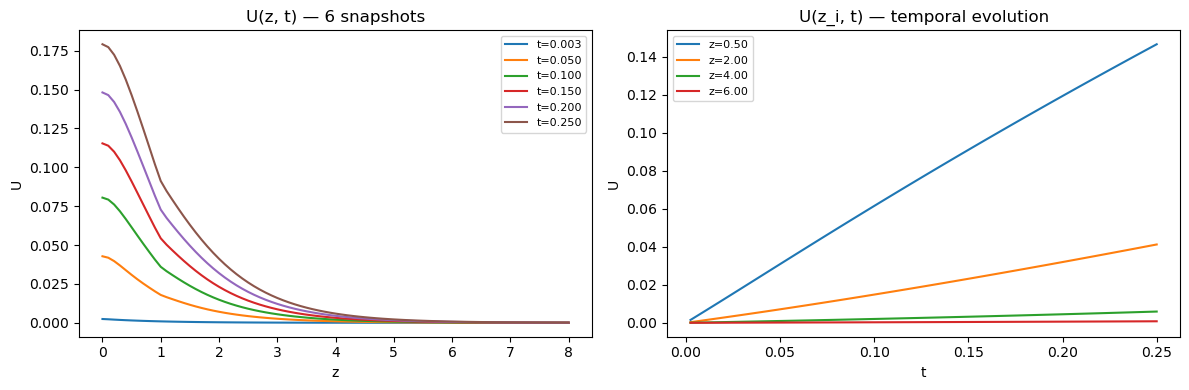

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

z_cpu = z.cpu(); U_cpu = U.cpu(); t_cpu = t_out.cpu()

# U(z): 6 evenly spaced snapshots
ax = axes[0]
idx = torch.linspace(0, U_cpu.shape[1]-1, 6).long()
for i in idx:
    ax.plot(z_cpu.numpy(), U_cpu[:, i].numpy(), label=f't={t_cpu[i]:.3f}')
ax.set_xlabel('z'); ax.set_ylabel('U')
ax.set_title('U(z, t) — 6 snapshots')
ax.legend(fontsize=8)

# U(t) at 4 z locations
ax = axes[1]
nz = z.shape[0] - 1
for iz in [5, nz//4, nz//2, 3*nz//4]:
    ax.plot(t_cpu.numpy(), U_cpu[iz, :].numpy(), label=f'z={z_cpu[iz]:.2f}')
ax.set_xlabel('t'); ax.set_ylabel('U')
ax.set_title('U(z_i, t) — temporal evolution')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Save dataset

In [ ]:
import os; os.makedirs('./train', exist_ok=True)

n_sub_t = t_out.shape[0]
nz      = z.shape[0] - 1

data_to_save = {
    'z':       z,
    't_out':   t_out,
    'U':       U,          # (nz+1, n_sub_t)
    'Delta_d': Delta_d,
    'k1':      k1,
    'k2':      k2,
    'kratio':  k1 / k2,
    'z_dis':   z_dis,
    'Pda':     Pda,
    'tf':      tf,
}

outfile = f'./train/2L_FD_nz{nz}_nsub{n_sub_t}_zc{z_dis}.pt'
torch.save(data_to_save, outfile)
print(f'Saved to {outfile}')
